# Nulling CDF Simulation


In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2
from sionna.rt import load_scene

import SceneConfigSionna
import nulling_cdf_utils as ncu

importlib.reload(SceneConfigSionna)
importlib.reload(ncu)

from SceneConfigSionna import SceneConfigSionna



In [2]:
# scene = load_scene("blender_scene_big/10km_times_10km/10km_times_10km.xml")
scene = load_scene("/workspace/shizhen/NTN-Nulling/Denver_Scene/Boulder/Boulder.xml")
SceneConfig = SceneConfigSionna(scene)
SceneConfig.build_coverage_map(grid_size=10, show_xy=True, plot=False)


x range: [-3002.648, 2997.352]
y range: [-3010.112, 2999.888]


## Simulation Parameters


In [3]:
# Geometry and deployment
ntn_rx = 200
tn_rx = 300
# bs_row = 2
# bs_col = 2
bs_row = 1
bs_col = 1
nbs = bs_row * bs_col
nsect = 3

# Satellite sampling configuration for Monte Carlo
satellite_resample_per_macro = True
satellite_azimuth_range_deg = (0.0, 360.0)
satellite_elevation_range_deg = (35.0, 90.0)

# Fallback values used only when per-macro resampling is disabled
azimuth = float(satellite_azimuth_range_deg[0])
elevation = float(satellite_elevation_range_deg[0])

# Carrier and array configuration
fc = 9.99e9
tx_antenna_rows = 8
tx_antenna_cols = 8
tn_rx_antenna_rows = 1
tn_rx_antenna_cols = 1
tx_antennas = tx_antenna_rows * tx_antenna_cols

# TX sector orientation
# Sionna orientation order: [yaw, pitch, roll]
tx_sector_yaw_offset_deg = 0.0
tx_head_down_deg = 5.0
tx_sector_roll_deg = 0.0

tx_sector_yaw_offset_rad = np.deg2rad(tx_sector_yaw_offset_deg)
tx_sector_pitch_rad = -np.deg2rad(tx_head_down_deg)
tx_sector_roll_rad = np.deg2rad(tx_sector_roll_deg)

# Monte Carlo setting
num_macro_sims = 3
show_progress = True
plot_layout_on_first_sim = False

print(
    f"TX sector orientation: yaw_offset={tx_sector_yaw_offset_deg:.1f} deg, "
    f"head_down={tx_head_down_deg:.1f} deg, roll={tx_sector_roll_deg:.1f} deg"
)
print(
    "Satellite sampling: "
    f"per_macro={satellite_resample_per_macro}, "
    f"azimuth_range={satellite_azimuth_range_deg}, "
    f"elevation_range={satellite_elevation_range_deg}"
)


TX sector orientation: yaw_offset=0.0 deg, head_down=5.0 deg, roll=0.0 deg
Satellite sampling: per_macro=True, azimuth_range=(0.0, 360.0), elevation_range=(35.0, 90.0)


In [4]:
# Noise, thresholds, and MUSIC setup
EkT = -174
B = 100e6
Tx_power_dbm = 35
Tx_power = 10 ** ((Tx_power_dbm - 30) / 10)
Tx_power_handheld_dbm = 23
Tx_power_handheld = 10 ** ((Tx_power_handheld_dbm - 30) / 10)
NTN_Tx_power_dbm = 30
NTN_Tx_power = 10 ** ((NTN_Tx_power_dbm - 30) / 10)


NF = 7
NF_vsat = 3
NF_bs = 2
N0_dBm = EkT + 10 * np.log10(B) + NF
N0 = 10 ** ((N0_dBm - 30) / 10)
N0_vsat = 10 ** ((EkT + 10 * np.log10(B) + NF_vsat - 30) / 10)
N0_bs = 10 ** ((EkT + 10 * np.log10(B) + NF_bs - 30) / 10)

preamble_time = 20e-6
N0_sigma = N0_vsat / Tx_power / preamble_time
N0_sigma_handheld = 10 ** ((EkT + NF_bs - 30) / 10) / Tx_power_handheld / preamble_time

# lambda_ranges = [1e10, 1e11, 1e12]
lambda_ranges = [1e1, 1e2, 1e3]
max_detected_b_terms = "all"  # use "all" or a positive integer such as 30
# max_detected_b_terms = 23 # use "all" or a positive integer such as 30
snr_threshold = -6
inr_threshold = -6
h_ntn_th = np.sqrt(10 ** (inr_threshold / 10) * N0_bs * tx_antennas / Tx_power)
h_tn_th = np.sqrt(10 ** (snr_threshold / 10) * N0_bs * tx_antennas / Tx_power)
threshold_peft_db = 10 * np.log10(np.abs(h_tn_th) ** 2)
p_fa = 1 / B
pfa_threshold = chi2.ppf(1 - p_fa, 2 * tx_antennas) / 2
h_ntn_pfa_th = np.sqrt(pfa_threshold * N0_sigma)
h_tn_pfa_th = np.sqrt(pfa_threshold * N0_sigma_handheld)
threshold_ntn_pfa_db = 10 * np.log10(np.abs(h_ntn_pfa_th) ** 2)
threshold_tn_pfa_db = 10 * np.log10(np.abs(h_tn_pfa_th) ** 2)

sionna_phi_is_global = True
theta_display_mode = "elevation"

music_num_sources = None
music_threshold = 3.0
music_covariance_mode = "sample"
music_num_snapshots = 200
music_noise_var = N0_bs / NTN_Tx_power
music_rng_seed = 7
music_source_estimation = "mdl"
music_energy_ratio = 0.95
music_reduce_ntn_ant = "max"
music_user_powers = None
music_use_sector_orientation = True
music_sector_pitch_rad = float(tx_sector_pitch_rad)
music_sector_roll_rad = float(tx_sector_roll_rad)
music_rotation_order = "zyx"
music_std_channel_mode = "conj"
music_std_manifold_label = "yz:+1"
music_std_flatten_order = "F"
music_std_scan_mode = "complex"
music_std_phi_offset_deg = 0.0
music_std_phi_mirror_about_sector = False
music_std_horizontal_sign = -1
music_sector_forward_only = True
music_sector_forward_cos_min = 0.0
music_phi_grid_deg = np.arange(0.0, 360.0, 1.0)
music_theta_grid_deg = np.arange(0.0, 181.0, 1.0)

print(f"h_tn_th = {h_tn_th:.4e}")
print(f"h_ntn_th = {h_ntn_th:.4e}")
print(f"TN Pfa threshold = {threshold_tn_pfa_db:.2f} dB")
print(f"NTN Pfa threshold = {threshold_ntn_pfa_db:.2f} dB")
print(f"Beamforming threshold = {threshold_peft_db:.2f} dB")
print(f"Max detected B terms per TX = {max_detected_b_terms}")
print("Top-K selection uses MUSIC reliability score = score_user * fit_score")



h_tn_th = 1.7910e-06
h_ntn_th = 1.7910e-06
TN Pfa threshold = -127.24 dB
NTN Pfa threshold = -58.24 dB
Beamforming threshold = -114.94 dB
Max detected B terms per TX = all
Top-K selection uses MUSIC reliability score = score_user * fit_score


## Monte Carlo Experiment

- Each macro simulation calls `compute_positions(...)` and `compute_paths(...)`.
- BS locations remain fixed because the same grid deployment is used in every macro simulation.
- TN users are paired to the strongest valid TX over all BS sectors.
- If the minimum number of paired TN users across all TX sectors is `m`, each macro simulation runs exactly `m` small rounds.
- In each small round, every TX serves one paired TN and nulls all NTN users detected by MUSIC for that TX.
- INR is computed as the sum of interference powers from all TX beams over the noise power.


In [5]:
import importlib
import nulling_cdf_utils as ncu
importlib.reload(ncu)

result_dir = Path("result")
result_dir.mkdir(parents=True, exist_ok=True)

compute_positions_kwargs_mc = dict(
    ntn_rx=ntn_rx,
    tn_rx=tn_rx,
    azimuth=azimuth,
    elevation=elevation,
    # centerBS=False,
    centerBS=True,
    bs_grid=(bs_row, bs_col),
    bs_boundary=2500,
    tn_building_ratio=0.6,
    # tn_building_ratio="sector ",
    tn_distance=400,
    ntn_building_ratio=0.6,
    plot_grid=plot_layout_on_first_sim,
    plot_bs=plot_layout_on_first_sim,
    plot_tn=plot_layout_on_first_sim,
    plot_ntn=plot_layout_on_first_sim,
)

compute_paths_kwargs_mc = dict(
    nsect=nsect,
    fc=fc,
    tx_rows=tx_antenna_rows,
    tx_cols=tx_antenna_cols,
    tn_rx_rows=tn_rx_antenna_rows,
    tn_rx_cols=tn_rx_antenna_cols,
    max_depth=0,
    bandwidth=B,
    tx_power_dbm=Tx_power_dbm,
    sector_yaw_offset_rad=tx_sector_yaw_offset_rad,
    sector_pitch_rad=tx_sector_pitch_rad,
    sector_roll_rad=tx_sector_roll_rad,
)

music_kwargs_mc = dict(
    tx_rows=int(tx_antenna_rows),
    tx_cols=int(tx_antenna_cols),
    nsect=int(nsect),
    pair_keys=None,
    detect_num_sources=music_num_sources,
    detect_threshold=music_threshold,
    detect_user_powers=music_user_powers,
    detect_noise_var=music_noise_var,
    detect_covariance_mode=music_covariance_mode,
    detect_num_snapshots=music_num_snapshots,
    detect_rng_seed=music_rng_seed,
    detect_source_estimation=music_source_estimation,
    detect_energy_ratio=music_energy_ratio,
    detect_reduce_rx_ant=music_reduce_ntn_ant,
    channel_mode=music_std_channel_mode,
    manifold_label=music_std_manifold_label,
    flatten_order=music_std_flatten_order,
    scan_mode=music_std_scan_mode,
    phi_offset_deg=music_std_phi_offset_deg,
    phi_mirror_about_sector=music_std_phi_mirror_about_sector,
    steering_horizontal_sign=music_std_horizontal_sign,
    use_sector_orientation=music_use_sector_orientation,
    sector_pitch_rad=music_sector_pitch_rad,
    sector_roll_rad=music_sector_roll_rad,
    rotation_order=music_rotation_order,
    sector_forward_only=music_sector_forward_only,
    sector_forward_cos_min=music_sector_forward_cos_min,
    phi_grid_deg=music_phi_grid_deg,
    theta_grid_deg=music_theta_grid_deg,
)

nulling_cdf_results = ncu.run_nulling_cdf_experiment(
    SceneConfig,
    num_macro_sims=num_macro_sims,
    compute_positions_kwargs=compute_positions_kwargs_mc,
    compute_paths_kwargs=compute_paths_kwargs_mc,
    lambda_ranges=lambda_ranges,
    h_tn_th=h_tn_th,
    tx_antennas=tx_antennas,
    tx_power=Tx_power,
    snr_noise_power=N0,
    inr_noise_power=N0_vsat,
    music_kwargs=music_kwargs_mc,
    sionna_phi_is_global=sionna_phi_is_global,
    theta_display_mode=theta_display_mode,
    plot_first_sim_only=plot_layout_on_first_sim,
    show_progress=show_progress,
    resample_satellite_per_macro=satellite_resample_per_macro,
    satellite_azimuth_range_deg=satellite_azimuth_range_deg,
    satellite_elevation_range_deg=satellite_elevation_range_deg,
    max_detected_b_terms=max_detected_b_terms,
)

metrics_path = ncu.save_experiment_metrics(
    nulling_cdf_results,
    result_dir=result_dir,
    output_name="nulling_cdf_metrics.npz",
)

macro_stats = nulling_cdf_results["macro_stats"]
macro_min_count = np.asarray([row["min_count"] for row in macro_stats], dtype=int)
macro_detected_ntn = np.asarray([row["detected_ntn_count"] for row in macro_stats], dtype=int)
macro_interfered_ntn = np.asarray([row["interfered_ntn_count"] for row in macro_stats], dtype=int)
macro_satellite_azimuth_deg = np.asarray([row["satellite_azimuth_deg"] for row in macro_stats], dtype=np.float64)
macro_satellite_elevation_deg = np.asarray([row["satellite_elevation_deg"] for row in macro_stats], dtype=np.float64)
macro_phi_mae_deg = np.asarray([row["angle_metrics"].get("phi_mae_deg", np.nan) for row in macro_stats], dtype=np.float64)
macro_elev_mae_deg = np.asarray([row["angle_metrics"].get("elev_mae_deg", np.nan) for row in macro_stats], dtype=np.float64)
macro_angle_match_count = np.asarray([row["angle_metrics"].get("matched_pairs", 0) for row in macro_stats], dtype=int)
macro_subset_count = np.asarray([row["detected_subset_metrics"].get("count", 0) for row in macro_stats], dtype=np.float64)
macro_subset_nrmse = np.asarray([row["detected_subset_metrics"].get("nrmse", np.nan) for row in macro_stats], dtype=np.float64)
macro_subset_cos_sim = np.asarray([row["detected_subset_metrics"].get("cos_sim", np.nan) for row in macro_stats], dtype=np.float64)
macro_subset_mag_mae = np.asarray([row["detected_subset_metrics"].get("mag_mae", np.nan) for row in macro_stats], dtype=np.float64)
macro_subset_power_ratio_db = np.asarray([row["detected_subset_metrics"].get("power_ratio_db", np.nan) for row in macro_stats], dtype=np.float64)
macro_pairs_count = np.asarray([row["detected_pairs_summary"].get("pairs", 0) for row in macro_stats], dtype=int)
macro_pairs_nrmse_mean = np.asarray([row["detected_pairs_summary"].get("nrmse_mean", np.nan) for row in macro_stats], dtype=np.float64)
macro_pairs_nrmse_median = np.asarray([row["detected_pairs_summary"].get("nrmse_median", np.nan) for row in macro_stats], dtype=np.float64)
macro_pairs_cos_mean = np.asarray([row["detected_pairs_summary"].get("cos_mean", np.nan) for row in macro_stats], dtype=np.float64)
macro_pairs_cos_median = np.asarray([row["detected_pairs_summary"].get("cos_median", np.nan) for row in macro_stats], dtype=np.float64)
tx_pos_ref = np.asarray(nulling_cdf_results.get("bs_pos_ref", np.empty((0, 3))), dtype=np.float64)

print(f"Number of macro simulations: {num_macro_sims}")
print(f"Macro simulations with min_count > 0: {np.count_nonzero(macro_min_count > 0)}")
print(f"Average min_count: {macro_min_count.mean() if macro_min_count.size else 0:.2f}")
print(f"Average detected NTN count: {macro_detected_ntn.mean() if macro_detected_ntn.size else 0:.2f}")
print(f"Average interfered NTN count: {macro_interfered_ntn.mean() if macro_interfered_ntn.size else 0:.2f}")
print("Satellite angles by macro:")
for idx, (sat_az_deg, sat_el_deg) in enumerate(zip(macro_satellite_azimuth_deg, macro_satellite_elevation_deg)):
    print(f"  macro {idx}: az={sat_az_deg:.2f} deg, el={sat_el_deg:.2f} deg")
print(f"Average phi MAE: {np.nanmean(macro_phi_mae_deg) if macro_phi_mae_deg.size else np.nan:.3f} deg")
print(f"Average elevation MAE: {np.nanmean(macro_elev_mae_deg) if macro_elev_mae_deg.size else np.nan:.3f} deg")
print(f"Raw INR samples: {nulling_cdf_results['raw_inr_db'].size}")
print(f"Raw SNR samples: {nulling_cdf_results['raw_snr_db'].size}")
for lambda_ in lambda_ranges:
    print(
        f"lambda={lambda_:.0e}: "
        f"Perfect INR={nulling_cdf_results['perfect_inr_db'][float(lambda_)].size}, "
        f"Est INR={nulling_cdf_results['est_inr_db'][float(lambda_)].size}, "
        f"Perfect SNR={nulling_cdf_results['perfect_snr_db'][float(lambda_)].size}, "
        f"Est SNR={nulling_cdf_results['est_snr_db'][float(lambda_)].size}"
    )
print(f"Metrics saved to: {metrics_path}")

header = (
    f"{'sim':>3} {'m':>3} {'detNTN':>6} {'pathNTN':>7} {'angN':>5} {'phiMAE':>8} {'elevMAE':>8} "
    f"{'subN':>8} {'subNRMSE':>10} {'subCos':>8} {'sub|h|MAE':>10} {'subPR':>8} "
    f"{'pairN':>6} {'pairNRMSEm':>11} {'pairNRMSEd':>11} {'pairCosM':>9} {'pairCosD':>9}"
)
print()
print("Per-macro MUSIC summary")
print(header)
print("-" * len(header))
for idx, row in enumerate(macro_stats):
    print(
        f"{idx:3d} "
        f"{macro_min_count[idx]:3d} "
        f"{macro_detected_ntn[idx]:6d} "
        f"{macro_interfered_ntn[idx]:7d} "
        f"{macro_angle_match_count[idx]:5d} "
        f"{macro_phi_mae_deg[idx]:8.3f} "
        f"{macro_elev_mae_deg[idx]:8.3f} "
        f"{macro_subset_count[idx]:8.0f} "
        f"{macro_subset_nrmse[idx]:10.4e} "
        f"{macro_subset_cos_sim[idx]:8.4f} "
        f"{macro_subset_mag_mae[idx]:10.4e} "
        f"{macro_subset_power_ratio_db[idx]:8.3f} "
        f"{macro_pairs_count[idx]:6d} "
        f"{macro_pairs_nrmse_mean[idx]:11.4e} "
        f"{macro_pairs_nrmse_median[idx]:11.4e} "
        f"{macro_pairs_cos_mean[idx]:9.4f} "
        f"{macro_pairs_cos_median[idx]:9.4f}"
    )

print()
print("Per-macro B summary by TX")
print("BtrueNTN/BhatNTN = unique NTN count; BtrueK/BhatK = actual number of channel vectors summed in B.")
for idx, row in enumerate(macro_stats):
    b_true_ntn = np.asarray(row.get("b_true_ntn_count_by_tx", []), dtype=int)
    b_true_terms = np.asarray(row.get("b_true_term_count_by_tx", []), dtype=int)
    b_hat_ntn = np.asarray(row.get("b_hat_ntn_count_by_tx", []), dtype=int)
    b_hat_terms = np.asarray(row.get("b_hat_term_count_by_tx", []), dtype=int)
    print()
    print(f"Macro sim {idx}")
    tx_header = (
        f"{'tx':>3} {'x':>10} {'y':>10} {'z':>10} "
        f"{'BtrueNTN':>9} {'BtrueK':>8} {'BhatNTN':>8} {'BhatK':>7}"
    )
    print(tx_header)
    print("-" * len(tx_header))
    num_tx_rows = max(
        tx_pos_ref.shape[0] if tx_pos_ref.ndim == 2 else 0,
        b_true_ntn.size,
        b_true_terms.size,
        b_hat_ntn.size,
        b_hat_terms.size,
    )
    for tx_idx in range(num_tx_rows):
        if tx_pos_ref.ndim == 2 and tx_idx < tx_pos_ref.shape[0]:
            x_pos, y_pos, z_pos = tx_pos_ref[tx_idx, :3]
        else:
            x_pos, y_pos, z_pos = np.nan, np.nan, np.nan
        true_ntn = int(b_true_ntn[tx_idx]) if tx_idx < b_true_ntn.size else 0
        true_terms = int(b_true_terms[tx_idx]) if tx_idx < b_true_terms.size else 0
        hat_ntn = int(b_hat_ntn[tx_idx]) if tx_idx < b_hat_ntn.size else 0
        hat_terms = int(b_hat_terms[tx_idx]) if tx_idx < b_hat_terms.size else 0
        print(
            f"{tx_idx:3d} "
            f"{x_pos:10.1f} {y_pos:10.1f} {z_pos:10.1f} "
            f"{true_ntn:9d} {true_terms:8d} {hat_ntn:8d} {hat_terms:7d}"
        )




Monte Carlo:   0%|          | 0/3 [00:00<?, ?it/s]

Number of macro simulations: 3
Macro simulations with min_count > 0: 3
Average min_count: 47.33
Average detected NTN count: 118.67
Average interfered NTN count: 118.67
Satellite angles by macro:
  macro 0: az=104.00 deg, el=47.51 deg
  macro 1: az=270.59 deg, el=41.22 deg
  macro 2: az=29.79 deg, el=74.54 deg
Average phi MAE: 44.337 deg
Average elevation MAE: 3.308 deg
Raw INR samples: 16813
Raw SNR samples: 426
lambda=1e+01: Perfect INR=16813, Est INR=16813, Perfect SNR=426, Est SNR=426
lambda=1e+02: Perfect INR=16813, Est INR=16813, Perfect SNR=426, Est SNR=426
lambda=1e+03: Perfect INR=16813, Est INR=16813, Perfect SNR=426, Est SNR=426
Metrics saved to: result/nulling_cdf_metrics.npz

Per-macro MUSIC summary
sim   m detNTN pathNTN  angN   phiMAE  elevMAE     subN   subNRMSE   subCos  sub|h|MAE    subPR  pairN  pairNRMSEm  pairNRMSEd  pairCosM  pairCosD
------------------------------------------------------------------------------------------------------------------------------------

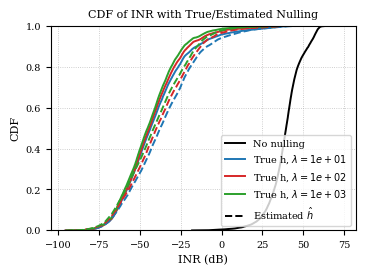

INR CDF PNG: result/nulling_inr_cdf66.png
INR CDF PDF: result/nulling_inr_cdf66.pdf


In [8]:
from matplotlib.lines import Line2D

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "lines.linewidth": 1.4,
    }
)

fig, ax = plt.subplots(figsize=(3.5, 2.6))

raw_inr = np.asarray(nulling_cdf_results["raw_inr_db"], dtype=np.float64)
raw_inr = raw_inr[np.isfinite(raw_inr)]
if raw_inr.size > 0:
    raw_inr_sorted = np.sort(raw_inr)
    raw_inr_cdf = np.arange(1, raw_inr_sorted.size + 1, dtype=np.float64) / float(raw_inr_sorted.size)
    ax.plot(raw_inr_sorted, raw_inr_cdf, color="black", linestyle="-", label="No nulling")

color_cycle = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#8c564b", "#17becf"]

for idx, lambda_ in enumerate(sorted(nulling_cdf_results["perfect_inr_db"].keys())):
    inr_values = np.asarray(nulling_cdf_results["perfect_inr_db"][lambda_], dtype=np.float64)
    inr_values = inr_values[np.isfinite(inr_values)]
    if inr_values.size == 0:
        continue

    inr_sorted = np.sort(inr_values)
    inr_cdf = np.arange(1, inr_sorted.size + 1, dtype=np.float64) / float(inr_sorted.size)
    ax.plot(
        inr_sorted,
        inr_cdf,
        color=color_cycle[idx % len(color_cycle)],
        linestyle="-",
        label=f"True h, $\\lambda={float(lambda_):.0e}$",
    )

for idx, lambda_ in enumerate(sorted(nulling_cdf_results["est_inr_db"].keys())):
    inr_values = np.asarray(nulling_cdf_results["est_inr_db"][lambda_], dtype=np.float64)
    inr_values = inr_values[np.isfinite(inr_values)]
    if inr_values.size == 0:
        continue

    inr_sorted = np.sort(inr_values)
    inr_cdf = np.arange(1, inr_sorted.size + 1, dtype=np.float64) / float(inr_sorted.size)
    ax.plot(
        inr_sorted,
        inr_cdf,
        color=color_cycle[idx % len(color_cycle)],
        linestyle="--",
    )

est_handle = Line2D([0], [0], color="black", linestyle="--", linewidth=1.4, label=r"Estimated $\hat{h}$")
handles, labels = ax.get_legend_handles_labels()
handles.append(est_handle)
labels.append(r"Estimated $\hat{h}$")

ax.set_xlabel("INR (dB)")
ax.set_ylabel("CDF")
ax.set_title("CDF of INR with True/Estimated Nulling")
ax.set_ylim(0.0, 1.0)
# ax.set_xlim(-70, 40)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.8)
ax.legend(handles=handles, labels=labels, loc="lower right", frameon=True)
fig.tight_layout(pad=0.2)

inr_png_path = result_dir / "nulling_inr_cdf66.png"
inr_pdf_path = result_dir / "nulling_inr_cdf66.pdf"
fig.savefig(inr_png_path, dpi=400, bbox_inches="tight")
fig.savefig(inr_pdf_path, bbox_inches="tight")
plt.show()

print(f"INR CDF PNG: {inr_png_path}")
print(f"INR CDF PDF: {inr_pdf_path}")



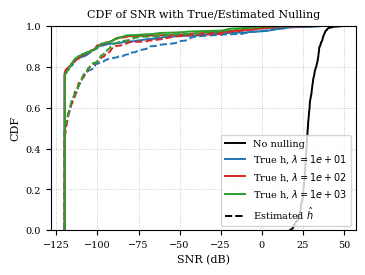

SNR CDF PNG: result/nulling_snr_cdf66.png
SNR CDF PDF: result/nulling_snr_cdf66.pdf


In [7]:
from matplotlib.lines import Line2D

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "lines.linewidth": 1.4,
    }
)

fig, ax = plt.subplots(figsize=(3.5, 2.6))

raw_snr = np.asarray(nulling_cdf_results["raw_snr_db"], dtype=np.float64)
raw_snr = raw_snr[np.isfinite(raw_snr)]
if raw_snr.size > 0:
    raw_snr_sorted = np.sort(raw_snr)
    raw_snr_cdf = np.arange(1, raw_snr_sorted.size + 1, dtype=np.float64) / float(raw_snr_sorted.size)
    ax.plot(raw_snr_sorted, raw_snr_cdf, color="black", linestyle="-", label="No nulling")

color_cycle = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#8c564b", "#17becf"]

for idx, lambda_ in enumerate(sorted(nulling_cdf_results["perfect_snr_db"].keys())):
    snr_values = np.asarray(nulling_cdf_results["perfect_snr_db"][lambda_], dtype=np.float64)
    snr_values = snr_values[np.isfinite(snr_values)]
    if snr_values.size == 0:
        continue

    snr_sorted = np.sort(snr_values)
    snr_cdf = np.arange(1, snr_sorted.size + 1, dtype=np.float64) / float(snr_sorted.size)
    ax.plot(
        snr_sorted,
        snr_cdf,
        color=color_cycle[idx % len(color_cycle)],
        linestyle="-",
        label=f"True h, $\\lambda={float(lambda_):.0e}$",
    )

for idx, lambda_ in enumerate(sorted(nulling_cdf_results["est_snr_db"].keys())):
    snr_values = np.asarray(nulling_cdf_results["est_snr_db"][lambda_], dtype=np.float64)
    snr_values = snr_values[np.isfinite(snr_values)]
    if snr_values.size == 0:
        continue

    snr_sorted = np.sort(snr_values)
    snr_cdf = np.arange(1, snr_sorted.size + 1, dtype=np.float64) / float(snr_sorted.size)
    ax.plot(
        snr_sorted,
        snr_cdf,
        color=color_cycle[idx % len(color_cycle)],
        linestyle="--",
    )

est_handle = Line2D([0], [0], color="black", linestyle="--", linewidth=1.4, label=r"Estimated $\hat{h}$")
handles, labels = ax.get_legend_handles_labels()
handles.append(est_handle)
labels.append(r"Estimated $\hat{h}$")

ax.set_xlabel("SNR (dB)")
ax.set_ylabel("CDF")
ax.set_title("CDF of SNR with True/Estimated Nulling")
ax.set_ylim(0.0, 1.0)
ax.grid(True, linestyle=":", linewidth=0.6, alpha=0.8)
ax.legend(handles=handles, labels=labels, loc="lower right", frameon=True)
fig.tight_layout(pad=0.2)

snr_png_path = result_dir / "nulling_snr_cdf66.png"
snr_pdf_path = result_dir / "nulling_snr_cdf66.pdf"
fig.savefig(snr_png_path, dpi=400, bbox_inches="tight")
fig.savefig(snr_pdf_path, bbox_inches="tight")
plt.show()

print(f"SNR CDF PNG: {snr_png_path}")
print(f"SNR CDF PDF: {snr_pdf_path}")

